### LOADING AND CONFIGURATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import os
import tensorflow as tf
from tensorflow.keras.layers import Layer
import joblib

DATA_PATH = r'D:\PJT2\CMAPSSData' 
PROCESSED_PATH = r'../../../processed_data' 
MODEL_PATH = r'./model_checkpoints'
WINDOW_SIZE = 60

### ATTENTION LAYER

In [2]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

### LOADING SMART ARTIFACTS

In [3]:
print("Loading FD004 MoE Brains & Artifacts...")
kmeans_op = joblib.load(os.path.join(PROCESSED_PATH, 'fd004_op_kmeans.pkl'))
regime_stats = joblib.load(os.path.join(PROCESSED_PATH, 'fd004_regime_stats.pkl'))

feature_scaler = joblib.load(os.path.join(PROCESSED_PATH, 'fd004_feature_scaler.pkl'))
signature_scaler = joblib.load(os.path.join(PROCESSED_PATH, 'fd004_signature_scaler.pkl'))
router_model = joblib.load(os.path.join(PROCESSED_PATH, 'fd004_router_model.pkl'))

model_c0 = load_model(os.path.join(MODEL_PATH, 'specialist_0_fd004.keras'), custom_objects={'Attention': Attention})
model_c1 = load_model(os.path.join(MODEL_PATH, 'specialist_1_fd004.keras'), custom_objects={'Attention': Attention})

lstm_features = feature_scaler.feature_names_in_.tolist()
router_features = signature_scaler.feature_names_in_.tolist()

Loading FD004 MoE Brains & Artifacts...



### PREPARING TEST DATA

In [4]:
print("Preparing Raw Test Data...")
cols = ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's{i}' for i in range(1, 22)]
test_df = pd.read_csv(os.path.join(DATA_PATH, 'test_FD004.txt'), sep='\s+', header=None, names=cols)
true_ruls = pd.read_csv(os.path.join(DATA_PATH, 'RUL_FD004.txt'), header=None, names=['RUL'])

Preparing Raw Test Data...


### Normalising

In [5]:
print("Preparing Stream A (Altitude-Free Data for Router)...")
setting_cols = ['setting_1', 'setting_2', 'setting_3']
sensor_cols = [f's{i}' for i in range(1, 22)]

test_df['op_cluster'] = kmeans_op.predict(test_df[setting_cols])
norm_test_df = test_df.copy()

norm_test_df[sensor_cols] = norm_test_df[sensor_cols].astype('float64')

for regime in range(6):
    mask = norm_test_df['op_cluster'] == regime
    for col in sensor_cols:
        mean_val = regime_stats.loc[regime, (col, 'mean')]
        std_val = regime_stats.loc[regime, (col, 'std')]
        if std_val > 1e-6:
            norm_test_df.loc[mask, col] = (norm_test_df.loc[mask, col] - mean_val) / std_val
        else:
            norm_test_df.loc[mask, col] = 0.0

Preparing Stream A (Altitude-Free Data for Router)...


In [6]:
print("Preparing Stream B (Raw Scaled Data for LSTMs)...")
lstm_test_df = test_df.copy()
lstm_test_df[lstm_features] = feature_scaler.transform(lstm_test_df[lstm_features])
lstm_test_df[lstm_features] = lstm_test_df.groupby('unit_number')[lstm_features].transform(lambda x: x.ewm(alpha=0.1).mean())

Preparing Stream B (Raw Scaled Data for LSTMs)...


### ROUTING AND PREDICTING

In [7]:
print("Routing Test Engines...")
final_predictions, actuals = [], []
routed_counts = {0: 0, 1: 0}

for unit_id in test_df['unit_number'].unique():
    
    #Asking the Router using STREAM A (norm_test_df)
    unit_data_router = norm_test_df[norm_test_df['unit_number'] == unit_id]
    clean_tail = unit_data_router[router_features].tail(5).mean().to_frame().T
    sig_scaled = signature_scaler.transform(clean_tail)
    assigned_cluster = router_model.predict(sig_scaled)[0]
    routed_counts[assigned_cluster] += 1
    
    #Extracting Window using STREAM B (lstm_test_df)
    unit_data_lstm = lstm_test_df[lstm_test_df['unit_number'] == unit_id]
    
    if len(unit_data_lstm) >= WINDOW_SIZE:
        seq = unit_data_lstm[lstm_features].values[-WINDOW_SIZE:].reshape(1, WINDOW_SIZE, len(lstm_features))
    else:
        padded_vals = np.pad(unit_data_lstm[lstm_features].values, ((WINDOW_SIZE - len(unit_data_lstm), 0), (0, 0)), 'constant', constant_values=0)
        seq = padded_vals.reshape(1, WINDOW_SIZE, len(lstm_features))
    
    #Predicting
    pred = model_c0.predict(seq, verbose=0)[0][0] if assigned_cluster == 0 else model_c1.predict(seq, verbose=0)[0][0]
        
    final_predictions.append(pred)
    actuals.append(true_ruls.iloc[unit_id-1].values[0])

Routing Test Engines...


### EVALUATION

In [8]:
final_rmse = np.sqrt(np.mean((np.array(final_predictions) - np.array(actuals)) ** 2))

print("\n" + "="*50)
print(f"Routed to Specialist 0: {routed_counts[0]}")
print(f"Routed to Specialist 1: {routed_counts[1]}")
print("-" * 30)
print(f"GLOBAL MODEL RMSE (Baseline): 40.56")
print(f"MIXTURE OF EXPERTS RMSE (Final): {final_rmse:.4f}")
print("="*50)


Routed to Specialist 0: 185
Routed to Specialist 1: 63
------------------------------
GLOBAL MODEL RMSE (Baseline): 40.56
MIXTURE OF EXPERTS RMSE (Final): 41.5112


### VISUALISING

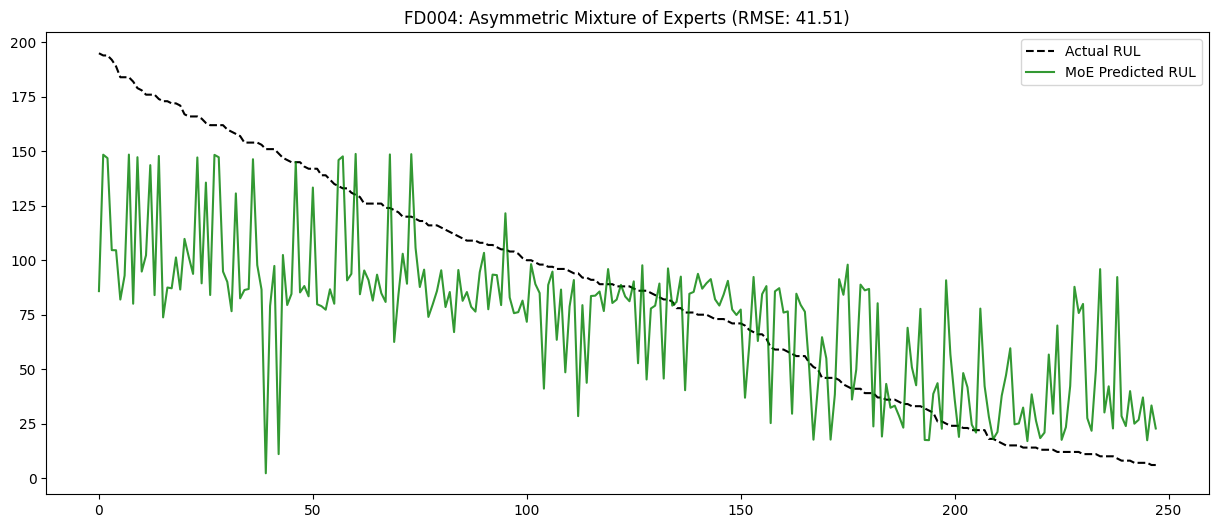

In [9]:
results_df = pd.DataFrame({'True': actuals, 'Pred': final_predictions}).sort_values('True', ascending=False).reset_index(drop=True)
plt.figure(figsize=(15, 6))
plt.plot(results_df['True'], label='Actual RUL', color='black', linestyle='--')
plt.plot(results_df['Pred'], label='MoE Predicted RUL', color='green', alpha=0.8)
plt.title(f'FD004: Asymmetric Mixture of Experts (RMSE: {final_rmse:.2f})')
plt.legend()
plt.show()